In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/intent_binary_best.pt
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/restorer_best.pt
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/quality_judge_best.pt
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepare

In [2]:
# =========================
# CELDA 1: Imports
# =========================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


In [3]:
# =========================
# CELDA 2: Arquitecturas
# =========================
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, dilation=1, drop=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(drop)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = self.drop(self.act(self.bn1(self.conv1(x))))
        x = self.drop(self.act(self.bn2(self.conv2(x))))
        return self.act(x + s)

class IntentTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.tcn = nn.Sequential(
            TCNBlock(16, 16, dilation=1, drop=0.10),
            TCNBlock(16, 32, dilation=2, drop=0.10),
            TCNBlock(32, 32, dilation=4, drop=0.10),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.tcn(x)
        x = self.pool(x)
        return self.head(x)

class QualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.head_score = nn.Linear(32, 1)
        self.head_label = nn.Linear(32, 1)

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        q_score = torch.sigmoid(self.head_score(z))
        q_logit = self.head_label(z)
        return q_score, q_logit

class ConvAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.bottleneck(z)
        y = self.decoder(z)
        return y


In [4]:
# =========================
# CELDA 3: Cargar modelos
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

MODELS_DIR = "/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1"

intent_model = IntentTCN().to(device)
intent_model.load_state_dict(torch.load(f"{MODELS_DIR}/intent_binary_best.pt", map_location=device))
intent_model.eval()

quality_model = QualityNet().to(device)
quality_model.load_state_dict(torch.load(f"{MODELS_DIR}/quality_judge_best.pt", map_location=device))
quality_model.eval()

restorer_model = ConvAE1D().to(device)
restorer_model.load_state_dict(torch.load(f"{MODELS_DIR}/restorer_best.pt", map_location=device))
restorer_model.eval()

print("Modelos cargados correctamente.")


device: cuda
Modelos cargados correctamente.


In [5]:
# =========================
# CELDA 4: Utilidades + dataset
# =========================
def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

def snr_db(clean, noisy):
    noise = noisy - clean
    ps = np.mean(clean**2) + 1e-8
    pn = np.mean(noise**2) + 1e-8
    return float(10 * np.log10(ps / pn))

def corrcoef_1d(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

candidate_dirs = []
for p in glob.glob("/kaggle/input/**/restoration_dataset", recursive=True):
    if os.path.isdir(p):
        xcorr = glob.glob(os.path.join(p, "Xcorr_*.npy"))
        xclean = glob.glob(os.path.join(p, "Xclean_*.npy"))
        qscore = glob.glob(os.path.join(p, "Qscore_*.npy"))
        if len(xcorr) > 0 and len(xclean) > 0 and len(qscore) > 0:
            candidate_dirs.append(p)

print("Candidatos encontrados:")
for c in candidate_dirs:
    print(" -", c)

if not candidate_dirs:
    raise FileNotFoundError("No encontré restoration_dataset.")

RDIR = candidate_dirs[0]

Xcorr_files = sorted(glob.glob(os.path.join(RDIR, "Xcorr_*.npy")))
Xclean_files = sorted(glob.glob(os.path.join(RDIR, "Xclean_*.npy")))
Qscore_files = sorted(glob.glob(os.path.join(RDIR, "Qscore_*.npy")))

print("restoration shards Xcorr:", len(Xcorr_files))
print("restoration shards Xclean:", len(Xclean_files))
print("restoration shards Qscore:", len(Qscore_files))

x_corr = np.load(Xcorr_files[0])
x_clean = np.load(Xclean_files[0])

N = min(3000, len(x_corr))
x_corr = x_corr[:N]
x_clean = x_clean[:N]

print("x_corr:", x_corr.shape)
print("x_clean:", x_clean.shape)


Candidatos encontrados:
 - /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset
restoration shards Xcorr: 32
restoration shards Xclean: 32
restoration shards Qscore: 32
x_corr: (3000, 1, 400)
x_clean: (3000, 1, 400)


In [6]:
# =========================
# CELDA 5: Política parametrizable
# =========================
@torch.no_grad()
def run_pipeline_on_batch(x_batch, thr_intent=0.50, thr_quality=0.50):
    xb = torch.tensor(x_batch, dtype=torch.float32, device=device)

    intent_logits = intent_model(xb)
    p_intent = torch.sigmoid(intent_logits).cpu().numpy().reshape(-1)

    q_score_pred, q_logit = quality_model(xb)
    q_score_pred = q_score_pred.cpu().numpy().reshape(-1)
    q_prob_good = torch.sigmoid(q_logit).cpu().numpy().reshape(-1)

    out = []
    restored = []

    for i in range(len(x_batch)):
        pi = float(p_intent[i])
        qg = float(q_prob_good[i])
        qs = float(q_score_pred[i])

        if pi < thr_intent:
            decision = "skip_restore"
            reason = "no_intent_detected"
        elif qg >= thr_quality:
            decision = "skip_restore"
            reason = "signal_quality_good_enough"
        else:
            decision = "restore"
            reason = "intent_detected_and_quality_bad"

        if decision == "restore":
            xr = restorer_model(xb[i:i+1]).cpu().numpy()[0]
        else:
            xr = x_batch[i].copy()

        restored.append(xr)
        out.append({
            "p_intent": pi,
            "q_score_pred": qs,
            "q_prob_good": qg,
            "decision": decision,
            "reason": reason
        })

    return out, np.stack(restored).astype(np.float32)


In [7]:
# =========================
# CELDA 6: Evaluar configuración
# =========================
def evaluate_pipeline_config(x_corr, x_clean, thr_intent=0.50, thr_quality=0.50):
    rows, x_out = run_pipeline_on_batch(x_corr, thr_intent=thr_intent, thr_quality=thr_quality)

    records = []
    for i, row in enumerate(rows):
        clean = x_clean[i, 0]
        corr  = x_corr[i, 0]
        out   = x_out[i, 0]

        records.append({
            **row,
            "mae_before": mae_np(clean, corr),
            "mae_after": mae_np(clean, out),
            "mse_before": mse_np(clean, corr),
            "mse_after": mse_np(clean, out),
            "snr_before": snr_db(clean, corr),
            "snr_after": snr_db(clean, out),
            "corr_before": corrcoef_1d(clean, corr),
            "corr_after": corrcoef_1d(clean, out),
            "improved_mae": mae_np(clean, out) < mae_np(clean, corr),
            "improved_snr": snr_db(clean, out) > snr_db(clean, corr),
        })

    df = pd.DataFrame(records)
    return df, x_out

df_base, x_out_base = evaluate_pipeline_config(x_corr, x_clean, thr_intent=0.50, thr_quality=0.50)
df_base.head()


,p_intent,q_score_pred,q_prob_good,decision,reason,mae_before,mae_after,mse_before,mse_after,snr_before,snr_after,corr_before,corr_after,improved_mae,improved_snr
0,0.885436,0.365641,0.000270,restore,intent_detected_and_quality_bad,2.026802,0.351064,9.462066,0.385402,6.711090,20.611813,0.965357,0.992565,True,True
1,0.278117,0.950326,0.996506,skip_restore,no_intent_detected,0.078784,0.078784,0.010018,0.010018,34.546997,34.546997,0.999728,0.999728,False,False
2,0.940655,0.999781,0.999999,skip_restore,signal_quality_good_enough,0.282560,0.282560,0.122476,0.122476,27.999830,27.999830,0.992411,0.992411,False,False
3,0.620910,0.423496,0.004911,restore,intent_detected_and_quality_bad,1.877942,0.362255,7.331492,0.396515,8.383072,21.052401,0.903180,0.981195,True,True
4,0.924138,0.999703,1.000000,skip_restore,signal_quality_good_enough,0.148471,0.148471,0.035670,0.035670,33.528049,33.528049,0.998370,0.998370,False,False


In [8]:
# =========================
# CELDA 7: Resumen detallado
# =========================
print("Conteo de decisiones:")
print(df_base["decision"].value_counts(dropna=False))
print()

print("Razones:")
print(df_base["reason"].value_counts(dropna=False))
print()

print("Promedios globales:")
print(df_base[["mae_before", "mae_after", "snr_before", "snr_after", "corr_before", "corr_after"]].mean())
print()

dfr = df_base[df_base["decision"] == "restore"]
print("Solo restauradas:")
print(dfr[["mae_before", "mae_after", "snr_before", "snr_after", "corr_before", "corr_after"]].mean())
print("Frac mejora MAE:", dfr["improved_mae"].mean())
print("Frac mejora SNR:", dfr["improved_snr"].mean())
print()

dfs = df_base[df_base["decision"] == "skip_restore"]
print("No restauradas por razón:")
print(dfs["reason"].value_counts(normalize=True))


Conteo de decisiones:
decision
skip_restore    2247
restore          753
Name: count, dtype: int64

Razones:
reason
signal_quality_good_enough         1351
no_intent_detected                  896
intent_detected_and_quality_bad     753
Name: count, dtype: int64

Promedios globales:
mae_before      0.892043
mae_after       0.467675
snr_before     23.204426
snr_after      24.970838
corr_before     0.920570
corr_after      0.941106
dtype: float64

Solo restauradas:
mae_before      2.316302
mae_after       0.625592
snr_before      8.797810
snr_after      15.835311
corr_before     0.848254
corr_after      0.930070
dtype: float64
Frac mejora MAE: 0.8100929614873837
Frac mejora SNR: 0.8273572377158035

No restauradas por razón:
reason
signal_quality_good_enough    0.601246
no_intent_detected            0.398754
Name: proportion, dtype: float64


No restauradas totales: 2247
reason
signal_quality_good_enough    1351
no_intent_detected             896
Name: count, dtype: int64


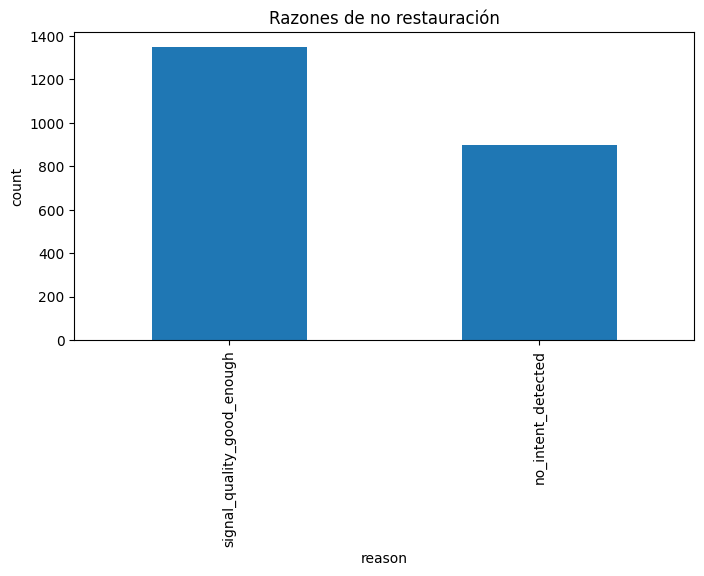

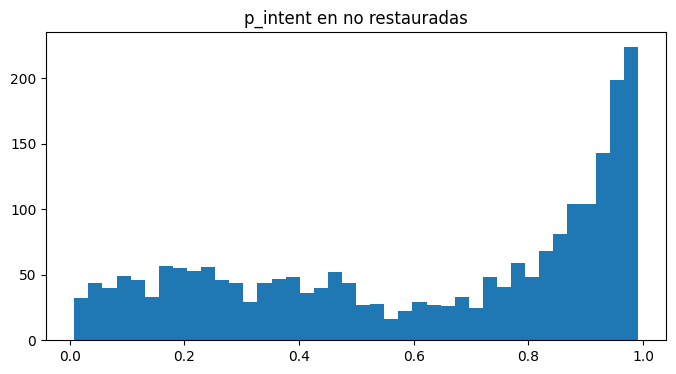

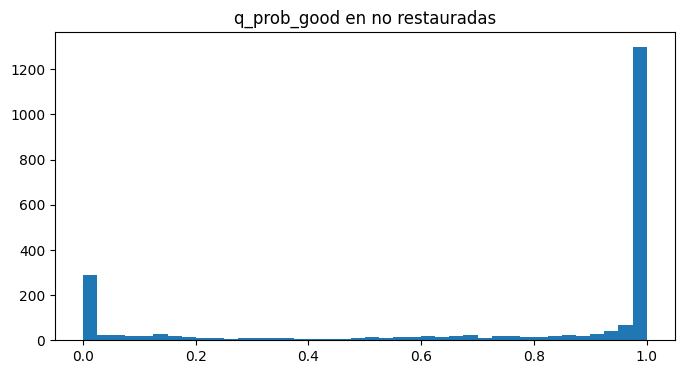

In [9]:
# =========================
# CELDA 8: No restauradas
# =========================
df_skip = df_base[df_base["decision"] == "skip_restore"].copy()

print("No restauradas totales:", len(df_skip))
print(df_skip["reason"].value_counts())

plt.figure(figsize=(8,4))
df_skip["reason"].value_counts().plot(kind="bar")
plt.title("Razones de no restauración")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_skip["p_intent"], bins=40)
plt.title("p_intent en no restauradas")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_skip["q_prob_good"], bins=40)
plt.title("q_prob_good en no restauradas")
plt.show()


Restauradas totales: 753
        delta_mae   delta_snr  delta_corr
count  753.000000  753.000000  753.000000
mean     1.690710    7.037501    0.081816
std      1.724668   13.956011    0.118464
min     -2.756996  -74.077778   -0.270901
25%      0.222497    3.017618    0.008831
50%      1.296159   10.032059    0.040553
75%      2.902323   14.670547    0.128283
max      7.086232   27.779855    0.856063


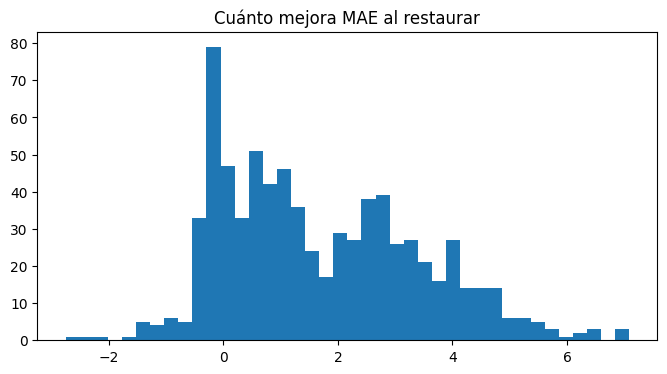

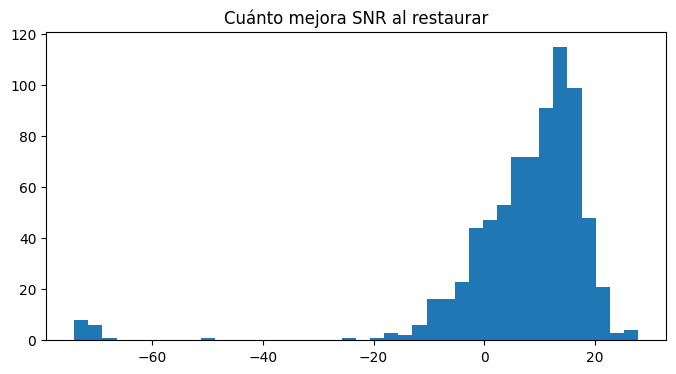

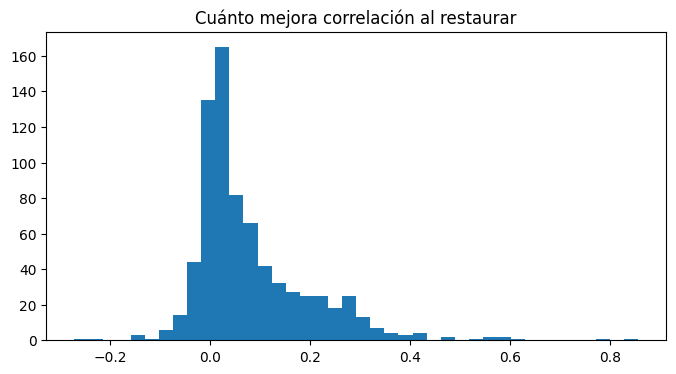

In [10]:
# =========================
# CELDA 9: Cuánto se restauran
# =========================
df_restore = df_base[df_base["decision"] == "restore"].copy()

df_restore["delta_mae"] = df_restore["mae_before"] - df_restore["mae_after"]
df_restore["delta_snr"] = df_restore["snr_after"] - df_restore["snr_before"]
df_restore["delta_corr"] = df_restore["corr_after"] - df_restore["corr_before"]

print("Restauradas totales:", len(df_restore))
print(df_restore[["delta_mae", "delta_snr", "delta_corr"]].describe())

plt.figure(figsize=(8,4))
plt.hist(df_restore["delta_mae"], bins=40)
plt.title("Cuánto mejora MAE al restaurar")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_restore["delta_snr"], bins=40)
plt.title("Cuánto mejora SNR al restaurar")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_restore["delta_corr"], bins=40)
plt.title("Cuánto mejora correlación al restaurar")
plt.show()


idx=0
reason=intent_detected_and_quality_bad
p_intent=0.885 | q_score_pred=0.366 | q_prob_good=0.000
MAE: 2.0268 -> 0.3511
SNR: 6.71 -> 20.61
Corr: 0.965 -> 0.993


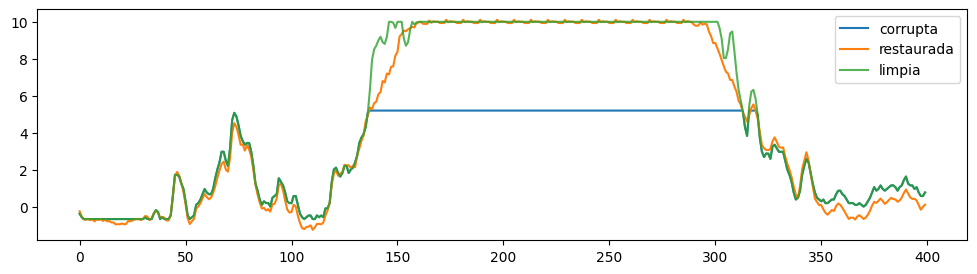

idx=3
reason=intent_detected_and_quality_bad
p_intent=0.621 | q_score_pred=0.423 | q_prob_good=0.005
MAE: 1.8779 -> 0.3623
SNR: 8.38 -> 21.05
Corr: 0.903 -> 0.981


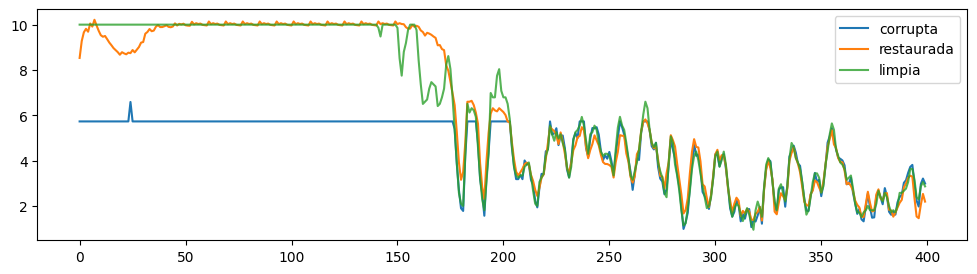

idx=6
reason=intent_detected_and_quality_bad
p_intent=0.886 | q_score_pred=0.512 | q_prob_good=0.124
MAE: 1.0194 -> 0.2984
SNR: 8.44 -> 23.68
Corr: 0.761 -> 0.993


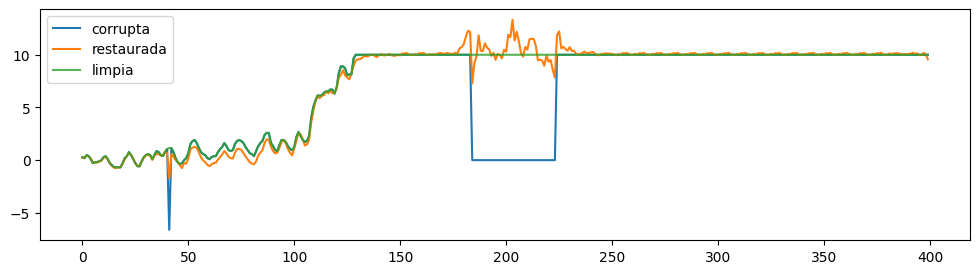

idx=20
reason=intent_detected_and_quality_bad
p_intent=0.826 | q_score_pred=0.377 | q_prob_good=0.000
MAE: 2.0089 -> 0.2169
SNR: 7.94 -> 24.43
Corr: 0.991 -> 0.996


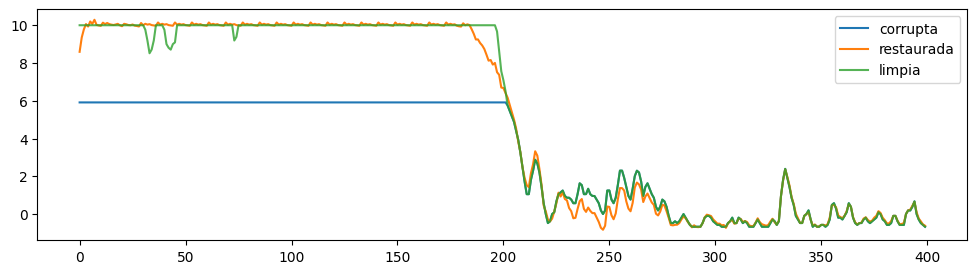

idx=24
reason=intent_detected_and_quality_bad
p_intent=0.523 | q_score_pred=0.406 | q_prob_good=0.052
MAE: 0.2483 -> 0.4559
SNR: 13.07 -> 11.69
Corr: 0.975 -> 0.953


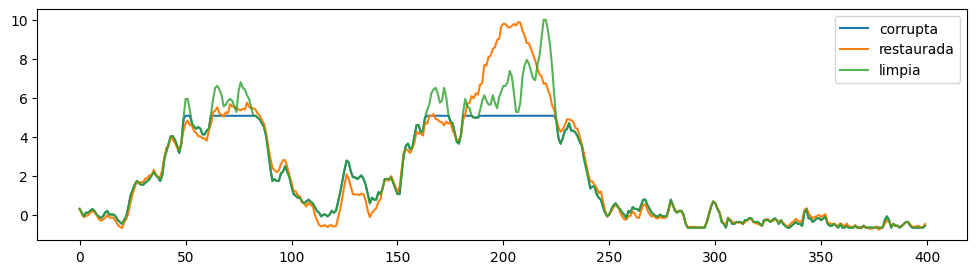

In [11]:
# =========================
# CELDA 10: Ejemplos restaurados
# =========================
restore_idx = df_base.index[df_base["decision"] == "restore"][:5]

for i in restore_idx:
    row = df_base.iloc[i]
    clean = x_clean[i, 0]
    corr = x_corr[i, 0]
    out = x_out_base[i, 0]

    print(f"idx={i}")
    print(f"reason={row['reason']}")
    print(f"p_intent={row['p_intent']:.3f} | q_score_pred={row['q_score_pred']:.3f} | q_prob_good={row['q_prob_good']:.3f}")
    print(f"MAE: {row['mae_before']:.4f} -> {row['mae_after']:.4f}")
    print(f"SNR: {row['snr_before']:.2f} -> {row['snr_after']:.2f}")
    print(f"Corr: {row['corr_before']:.3f} -> {row['corr_after']:.3f}")

    plt.figure(figsize=(12,3))
    plt.plot(corr, label="corrupta")
    plt.plot(out, label="restaurada")
    plt.plot(clean, label="limpia", alpha=0.8)
    plt.legend()
    plt.show()


idx=1
reason=no_intent_detected
p_intent=0.278 | q_score_pred=0.950 | q_prob_good=0.997
MAE: 0.0788 -> 0.0788
SNR: 34.55 -> 34.55


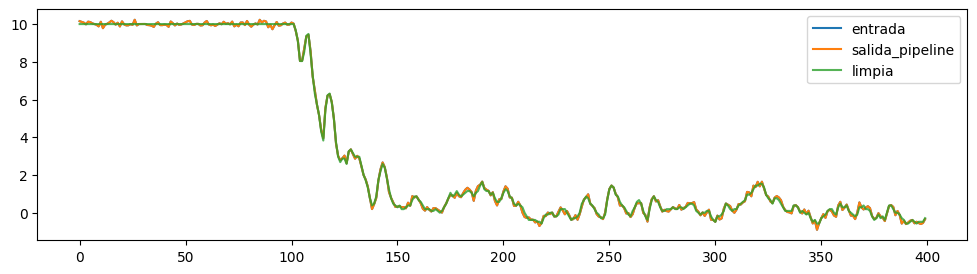

idx=2
reason=signal_quality_good_enough
p_intent=0.941 | q_score_pred=1.000 | q_prob_good=1.000
MAE: 0.2826 -> 0.2826
SNR: 28.00 -> 28.00


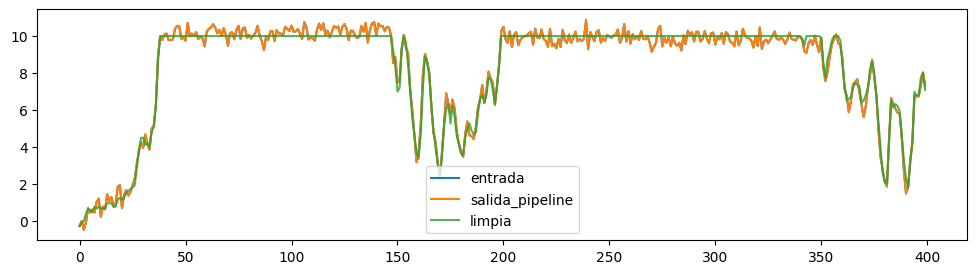

idx=4
reason=signal_quality_good_enough
p_intent=0.924 | q_score_pred=1.000 | q_prob_good=1.000
MAE: 0.1485 -> 0.1485
SNR: 33.53 -> 33.53


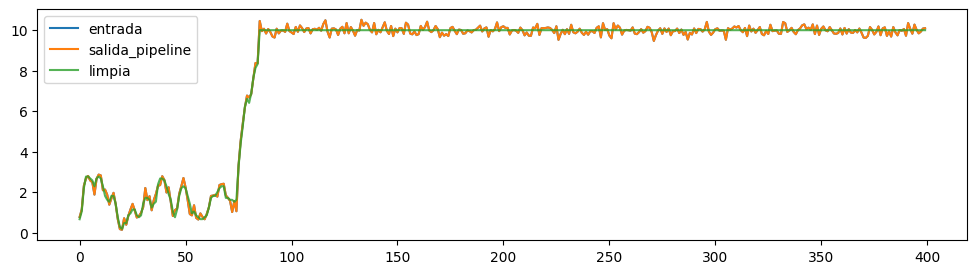

idx=5
reason=signal_quality_good_enough
p_intent=0.965 | q_score_pred=1.000 | q_prob_good=1.000
MAE: 0.0000 -> 0.0000
SNR: 99.05 -> 99.05


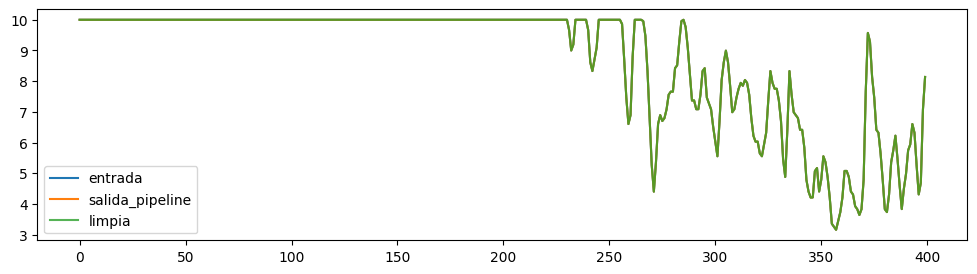

idx=7
reason=signal_quality_good_enough
p_intent=0.729 | q_score_pred=0.980 | q_prob_good=0.999
MAE: 0.2873 -> 0.2873
SNR: 22.41 -> 22.41


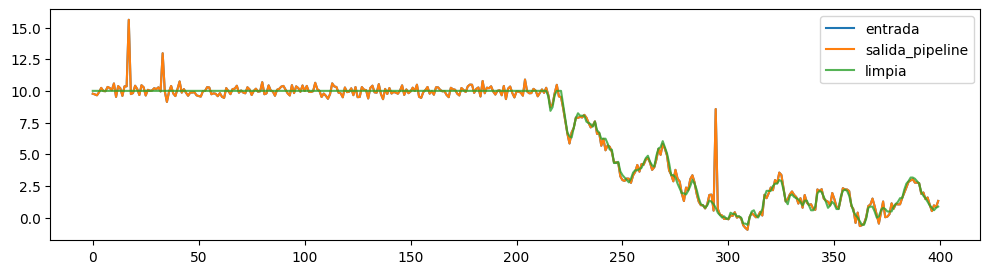

In [12]:
# =========================
# CELDA 11: Ejemplos no restaurados
# =========================
skip_idx = df_base.index[df_base["decision"] == "skip_restore"][:5]

for i in skip_idx:
    row = df_base.iloc[i]
    clean = x_clean[i, 0]
    corr = x_corr[i, 0]
    out = x_out_base[i, 0]

    print(f"idx={i}")
    print(f"reason={row['reason']}")
    print(f"p_intent={row['p_intent']:.3f} | q_score_pred={row['q_score_pred']:.3f} | q_prob_good={row['q_prob_good']:.3f}")
    print(f"MAE: {row['mae_before']:.4f} -> {row['mae_after']:.4f}")
    print(f"SNR: {row['snr_before']:.2f} -> {row['snr_after']:.2f}")

    plt.figure(figsize=(12,3))
    plt.plot(corr, label="entrada")
    plt.plot(out, label="salida_pipeline")
    plt.plot(clean, label="limpia", alpha=0.8)
    plt.legend()
    plt.show()


In [13]:
# =========================
# CELDA 12: Barrido de umbrales
# =========================
intent_grid = [0.40, 0.50, 0.60]
quality_grid = [0.40, 0.50, 0.60]

grid_rows = []

for ti in intent_grid:
    for tq in quality_grid:
        df_tmp, _ = evaluate_pipeline_config(x_corr, x_clean, thr_intent=ti, thr_quality=tq)

        dfr = df_tmp[df_tmp["decision"] == "restore"]
        restore_frac = len(dfr) / max(len(df_tmp), 1)

        row = {
            "thr_intent": ti,
            "thr_quality": tq,
            "restore_frac": restore_frac,
            "mae_before_global": df_tmp["mae_before"].mean(),
            "mae_after_global": df_tmp["mae_after"].mean(),
            "snr_before_global": df_tmp["snr_before"].mean(),
            "snr_after_global": df_tmp["snr_after"].mean(),
            "mae_gain_global": df_tmp["mae_before"].mean() - df_tmp["mae_after"].mean(),
            "snr_gain_global": df_tmp["snr_after"].mean() - df_tmp["snr_before"].mean(),
            "restore_mae_gain": dfr["mae_before"].mean() - dfr["mae_after"].mean() if len(dfr) else np.nan,
            "restore_snr_gain": dfr["snr_after"].mean() - dfr["snr_before"].mean() if len(dfr) else np.nan,
            "restore_mae_improve_frac": dfr["improved_mae"].mean() if len(dfr) else np.nan,
            "restore_snr_improve_frac": dfr["improved_snr"].mean() if len(dfr) else np.nan,
        }
        grid_rows.append(row)

grid_df = pd.DataFrame(grid_rows)
grid_df.sort_values(["snr_gain_global", "mae_gain_global"], ascending=False)


,thr_intent,thr_quality,restore_frac,mae_before_global,mae_after_global,snr_before_global,snr_after_global,mae_gain_global,snr_gain_global,restore_mae_gain,restore_snr_gain,restore_mae_improve_frac,restore_snr_improve_frac
0,0.4,0.4,0.269667,0.892043,0.447835,23.204426,25.141473,0.444208,1.937047,1.647247,7.183115,0.813350,0.834363
3,0.5,0.4,0.246000,0.892043,0.467602,23.204426,25.047414,0.424441,1.842988,1.725368,7.491822,0.819783,0.838753
1,0.4,0.5,0.277667,0.892043,0.448176,23.204426,25.014724,0.443867,1.810298,1.598559,6.519680,0.799520,0.818727
4,0.5,0.5,0.251000,0.892043,0.467675,23.204426,24.970838,0.424368,1.766413,1.690710,7.037501,0.810093,0.827357
6,0.6,0.4,0.217667,0.892043,0.493250,23.204426,24.970234,0.398793,1.765808,1.832129,8.112443,0.842266,0.856049
5,0.5,0.6,0.257667,0.892043,0.466810,23.204426,24.947825,0.425233,1.743400,1.650322,6.766104,0.803364,0.821475
2,0.4,0.6,0.287000,0.892043,0.447653,23.204426,24.941052,0.444390,1.736626,1.548397,6.050963,0.788618,0.808362
7,0.6,0.5,0.222000,0.892043,0.493203,23.204426,24.917553,0.398840,1.713127,1.796576,7.716788,0.833333,0.845345
8,0.6,0.6,0.228000,0.892043,0.492361,23.204426,24.893902,0.399682,1.689477,1.752993,7.409985,0.826023,0.839181


   thr_intent  thr_quality  restore_frac  mae_before_global  mae_after_global  \
0         0.4          0.4      0.269667           0.892043          0.447835   
3         0.5          0.4      0.246000           0.892043          0.467602   
1         0.4          0.5      0.277667           0.892043          0.448176   
4         0.5          0.5      0.251000           0.892043          0.467675   
6         0.6          0.4      0.217667           0.892043          0.493250   
5         0.5          0.6      0.257667           0.892043          0.466810   
2         0.4          0.6      0.287000           0.892043          0.447653   
7         0.6          0.5      0.222000           0.892043          0.493203   
8         0.6          0.6      0.228000           0.892043          0.492361   

   snr_before_global  snr_after_global  mae_gain_global  snr_gain_global  \
0          23.204426         25.141473         0.444208         1.937047   
3          23.204426         25.04741

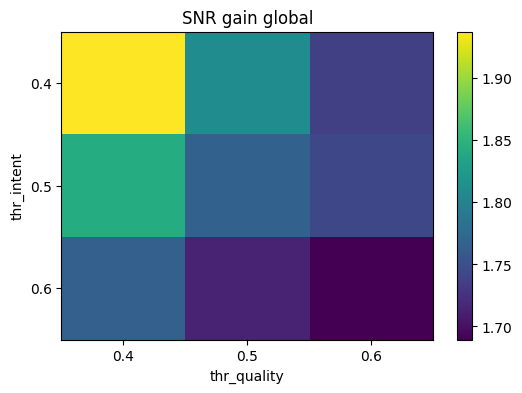

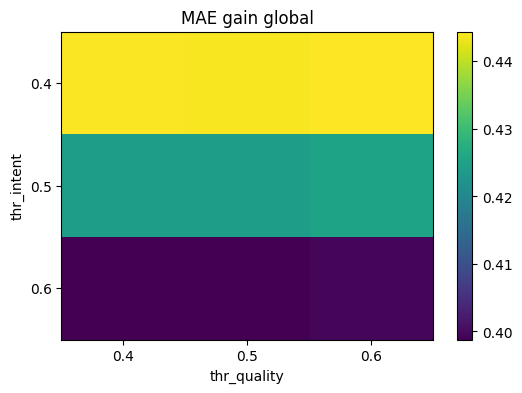

In [14]:
# =========================
# CELDA 13: Visualizar barrido
# =========================
print(grid_df.sort_values(["snr_gain_global", "mae_gain_global"], ascending=False))

pivot_snr = grid_df.pivot(index="thr_intent", columns="thr_quality", values="snr_gain_global")
pivot_mae = grid_df.pivot(index="thr_intent", columns="thr_quality", values="mae_gain_global")

plt.figure(figsize=(6,4))
plt.imshow(pivot_snr.values, aspect="auto")
plt.xticks(range(len(pivot_snr.columns)), pivot_snr.columns)
plt.yticks(range(len(pivot_snr.index)), pivot_snr.index)
plt.title("SNR gain global")
plt.xlabel("thr_quality")
plt.ylabel("thr_intent")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(pivot_mae.values, aspect="auto")
plt.xticks(range(len(pivot_mae.columns)), pivot_mae.columns)
plt.yticks(range(len(pivot_mae.index)), pivot_mae.index)
plt.title("MAE gain global")
plt.xlabel("thr_quality")
plt.ylabel("thr_intent")
plt.colorbar()
plt.show()


{'p_intent': 0.19128292798995972, 'q_score_pred': 0.1289299726486206, 'q_prob_good': 5.696972039004322e-06, 'decision': 'skip_restore', 'reason': 'no_intent_detected'}
MAE: 0.387653648853302 -> 0.387653648853302
SNR: -2.123706340789795 -> -2.123706340789795


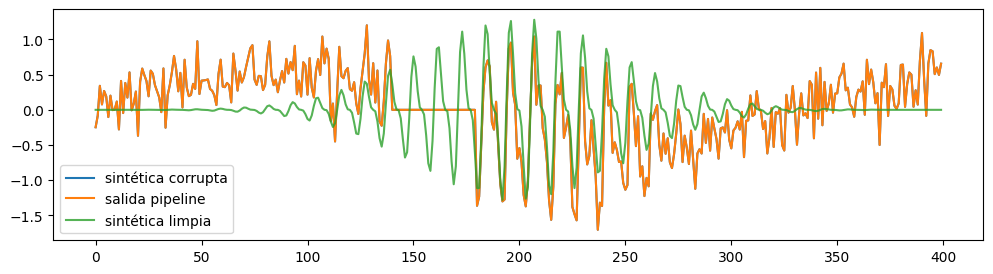

In [15]:
# =========================
# CELDA 14: Señal sintética
# =========================
def make_synthetic_emg_window(T=400, seed=123):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, T)

    clean = np.zeros(T, dtype=np.float32)
    burst_center = 0.5
    env = np.exp(-0.5 * ((t - burst_center) / 0.12)**2)
    carrier = np.sin(2*np.pi*35*t) + 0.5*np.sin(2*np.pi*70*t)
    clean = (env * carrier).astype(np.float32)

    noisy = clean.copy()
    noisy += rng.normal(0, 0.25, size=T).astype(np.float32)
    noisy += (0.5 * np.sin(2*np.pi*1.2*t)).astype(np.float32)

    start = 140
    noisy[start:start+40] = 0.0

    return clean[None, None, :].astype(np.float32), noisy[None, None, :].astype(np.float32)

x_clean_syn, x_corr_syn = make_synthetic_emg_window()

rows_syn, x_out_syn = run_pipeline_on_batch(x_corr_syn, thr_intent=0.50, thr_quality=0.50)
row = rows_syn[0]

print(row)
print("MAE:", mae_np(x_clean_syn[0,0], x_corr_syn[0,0]), "->", mae_np(x_clean_syn[0,0], x_out_syn[0,0]))
print("SNR:", snr_db(x_clean_syn[0,0], x_corr_syn[0,0]), "->", snr_db(x_clean_syn[0,0], x_out_syn[0,0]))

plt.figure(figsize=(12,3))
plt.plot(x_corr_syn[0,0], label="sintética corrupta")
plt.plot(x_out_syn[0,0], label="salida pipeline")
plt.plot(x_clean_syn[0,0], label="sintética limpia", alpha=0.8)
plt.legend()
plt.show()


In [16]:
# =========================
# CELDA 15: Señal externa tipo MyoWare
# =========================
# Ejemplos de rutas:
# external_path = "/kaggle/input/mi-senal-myoware/senal.csv"
# external_path = "/kaggle/input/mi-senal-myoware/senal.npy"

external_path = None  # cámbialo cuando subas tu archivo

def robust_norm_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    z = (x - med) / (1.4826 * mad)
    return np.clip(z, -10, 10).astype(np.float32)

def load_external_signal(path):
    if path.endswith(".npy"):
        sig = np.load(path).astype(np.float32).reshape(-1)
    elif path.endswith(".csv"):
        sig = np.loadtxt(path, delimiter=",", dtype=np.float32).reshape(-1)
    elif path.endswith(".txt"):
        sig = np.loadtxt(path, dtype=np.float32).reshape(-1)
    else:
        raise ValueError("Formato no soportado. Usa .npy, .csv o .txt")
    return robust_norm_1d(sig)

def windows_1d(sig, win=400, stride=200):
    idxs = np.arange(0, len(sig) - win + 1, stride)
    return np.stack([sig[i:i+win] for i in idxs], axis=0)[:, None, :].astype(np.float32)

if external_path is not None:
    sig = load_external_signal(external_path)
    x_ext = windows_1d(sig, win=400, stride=200)

    rows_ext, x_out_ext = run_pipeline_on_batch(x_ext, thr_intent=0.50, thr_quality=0.50)
    df_ext = pd.DataFrame(rows_ext)

    print(df_ext["decision"].value_counts(dropna=False))
    print(df_ext["reason"].value_counts(dropna=False))

    i = 0
    print(df_ext.iloc[i].to_dict())

    plt.figure(figsize=(12,3))
    plt.plot(x_ext[i,0], label="entrada externa")
    plt.plot(x_out_ext[i,0], label="salida pipeline")
    plt.legend()
    plt.show()
else:
    print("Sube una señal externa y asigna external_path para probar MyoWare.")


Sube una señal externa y asigna external_path para probar MyoWare.
